# WEEK 4 — EXPLORATORY DATA ANALYSIS
## Road Accident Dataset: Univariate & Bivariate Analysis
**Input:** `AccidentsBig_cleaned_week3.csv`

### Objectives
- Load and verify the cleaned Week 3 dataset.
- Perform univariate analysis on major accident variables.
- Perform bivariate analysis to study relationships between variables.
- Present findings using summary tables and visualizations.

> Several categorical fields are stored as numeric codes. The notebook preserves the dataset's original codes instead of inventing category names.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load Week 3 Cleaned Dataset

In [2]:
df = pd.read_csv("AccidentsBig_cleaned_week3.csv", low_memory=False)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1048575, 30)


,Accident_Index,longitude,latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,Time,Local_Authority_(District),Local_Authority_(Highway),1st_Road_Class,1st_Road_Number,Road_Type,Speed_limit,Junction_Detail,Junction_Control,2nd_Road_Class,2nd_Road_Number,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Date
0,1.0,78.610393,14.724026,1.0,2.0,1.0,1.0,3.0,17:42,12.0,E09000020,3.0,3218.0,6.0,30.0,0.0,-1.0,-1.0,0.0,0.0,1.0,1.0,2.0,2.0,0.0,0.0,1.0,1.0,E01002849,04-01-2018
1,2.0,78.534042,14.762353,1.0,3.0,1.0,1.0,4.0,17:36,12.0,E09000020,4.0,450.0,3.0,30.0,6.0,2.0,5.0,0.0,0.0,5.0,4.0,1.0,1.0,0.0,0.0,1.0,1.0,E01002909,05-01-2018
2,3.0,78.470877,14.745606,1.0,3.0,2.0,1.0,5.0,00:15,12.0,E09000020,5.0,0.0,6.0,30.0,0.0,-1.0,-1.0,0.0,0.0,0.0,4.0,1.0,1.0,0.0,0.0,1.0,1.0,E01002857,06-01-2018
3,4.0,78.557994,14.667128,1.0,3.0,1.0,1.0,6.0,10:35,12.0,E09000020,3.0,3220.0,6.0,30.0,0.0,-1.0,-1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,E01002840,07-01-2018
4,5.0,78.576431,14.703443,1.0,3.0,1.0,1.0,2.0,21:13,12.0,E09000020,6.0,0.0,6.0,30.0,0.0,-1.0,-1.0,0.0,0.0,0.0,7.0,1.0,2.0,0.0,0.0,1.0,1.0,E01002863,10-01-2018


## 3. Dataset Verification

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Rows: 1048575
Columns: 30
Missing values: 0
Duplicate rows: 988576


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 30 columns):
 #   Column                                       Non-Null Count    Dtype  
---  ------                                       --------------    -----  
 0   Accident_Index                               1048575 non-null  float64
 1   longitude                                    1048575 non-null  float64
 2   latitude                                     1048575 non-null  float64
 3   Police_Force                                 1048575 non-null  float64
 4   Accident_Severity                            1048575 non-null  float64
 5   Number_of_Vehicles                           1048575 non-null  float64
 6   Number_of_Casualties                         1048575 non-null  float64
 7   Day_of_Week                                  1048575 non-null  float64
 8   Time                                         1048575 non-null  object 
 9   Local_Authority_(District)                   1

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Accident_Index,1048575.0,29999.500000,4143.000588,1.000000,29999.500000,29999.500000,29999.500000,59998.000000
longitude,1048575.0,77.110717,1.443798,69.015103,77.050768,77.050768,77.050768,94.231931
latitude,1048575.0,22.695662,1.361174,8.864429,22.732800,22.732800,22.732800,31.068800
Police_Force,1048575.0,4.017415,1.095226,1.000000,4.000000,4.000000,4.000000,48.000000
Accident_Severity,1048575.0,2.991733,0.097114,1.000000,3.000000,3.000000,3.000000,3.000000
Number_of_Vehicles,1048575.0,1.990389,0.170250,1.000000,2.000000,2.000000,2.000000,18.000000
Number_of_Casualties,1048575.0,1.018353,0.196931,1.000000,1.000000,1.000000,1.000000,23.000000
Day_of_Week,1048575.0,4.007132,0.461061,1.000000,4.000000,4.000000,4.000000,7.000000
Local_Authority_(District),1048575.0,72.894207,15.273644,1.000000,73.000000,73.000000,73.000000,570.000000
1st_Road_Class,1048575.0,3.056199,0.397498,1.000000,3.000000,3.000000,3.000000,6.000000


# PART A — UNIVARIATE ANALYSIS
Univariate analysis examines **one variable at a time** to understand its frequency, distribution, central tendency and spread.


## 4. Accident Severity Distribution

Accident_Severity
1.0        646
2.0       7377
3.0    1040552
Name: count, dtype: int64


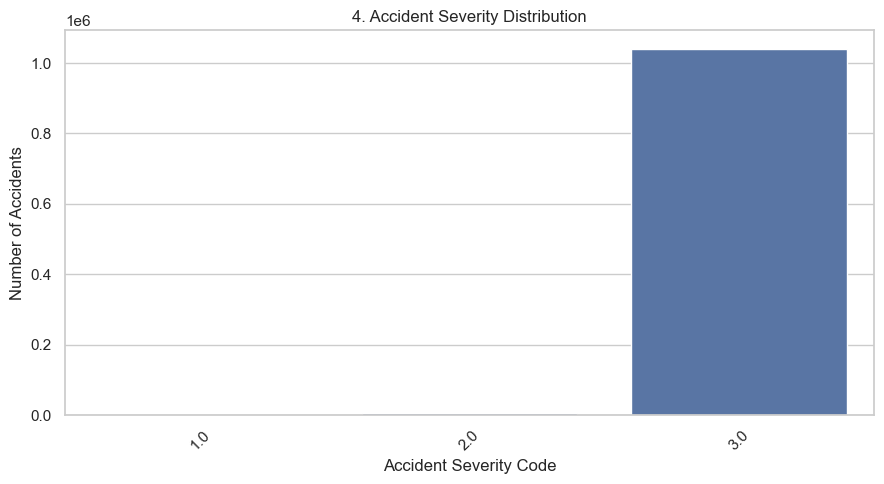

In [6]:
counts = df["Accident_Severity"].value_counts().sort_index()
print(counts)

plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Accident_Severity", order=counts.index)
plt.title("4. Accident Severity Distribution")
plt.xlabel("Accident Severity Code")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Number of Vehicles

Number_of_Vehicles
1.0       17679
2.0     1024947
3.0        4772
4.0         898
5.0         179
6.0          55
7.0          25
8.0          14
9.0           1
10.0          1
11.0          1
13.0          1
18.0          2
Name: count, dtype: int64


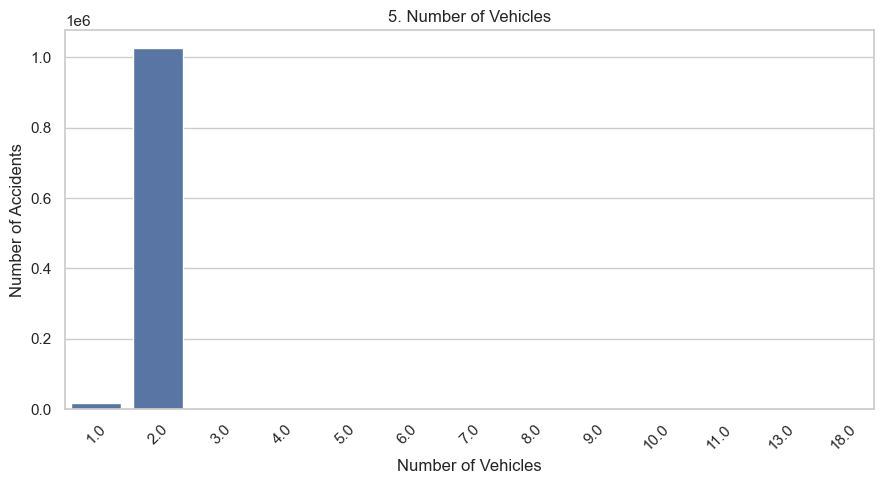

In [7]:
counts = df["Number_of_Vehicles"].value_counts().sort_index()
print(counts)

plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Number_of_Vehicles", order=counts.index)
plt.title("5. Number of Vehicles")
plt.xlabel("Number of Vehicles")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Number of Casualties

Number_of_Casualties
1.0     1035672
2.0        8996
3.0        2487
4.0         851
5.0         340
6.0         137
7.0          46
8.0          20
9.0          10
10.0          7
11.0          5
13.0          1
17.0          1
19.0          1
23.0          1
Name: count, dtype: int64


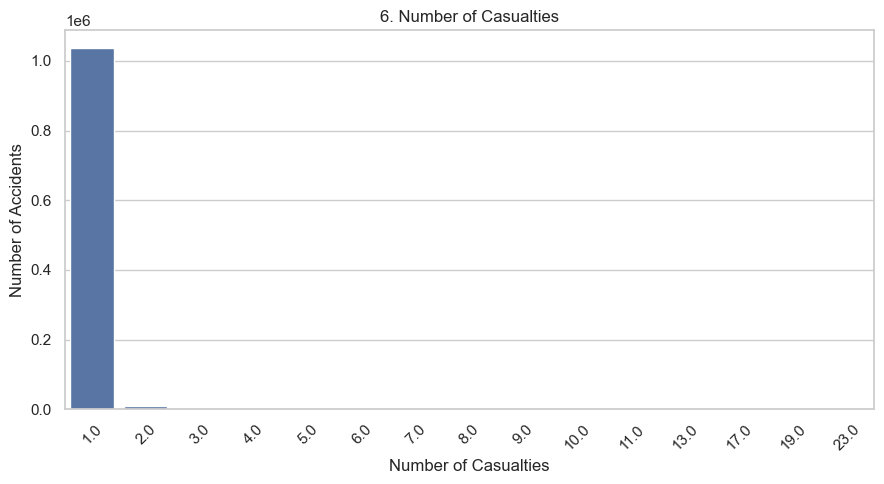

In [8]:
counts = df["Number_of_Casualties"].value_counts().sort_index()
print(counts)

plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Number_of_Casualties", order=counts.index)
plt.title("6. Number of Casualties")
plt.xlabel("Number of Casualties")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Accidents by Day of Week

Day_of_Week
1.0      6544
2.0      8407
3.0      9018
4.0    997752
5.0      8914
6.0      9792
7.0      8148
Name: count, dtype: int64


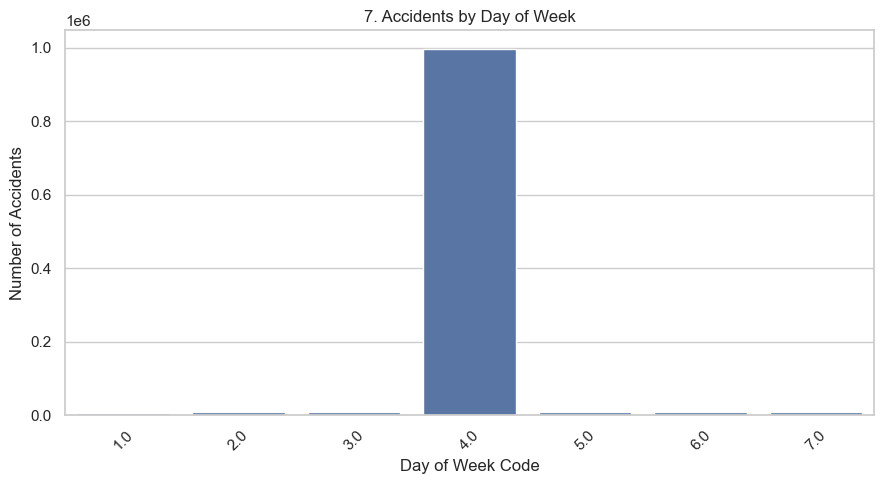

In [9]:
counts = df["Day_of_Week"].value_counts().sort_index()
print(counts)

plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Day_of_Week", order=counts.index)
plt.title("7. Accidents by Day of Week")
plt.xlabel("Day of Week Code")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Accidents by Speed Limit

Speed_limit
10.0          1
20.0        256
30.0    1036502
40.0       3128
50.0       1364
60.0       4565
70.0       2759
Name: count, dtype: int64


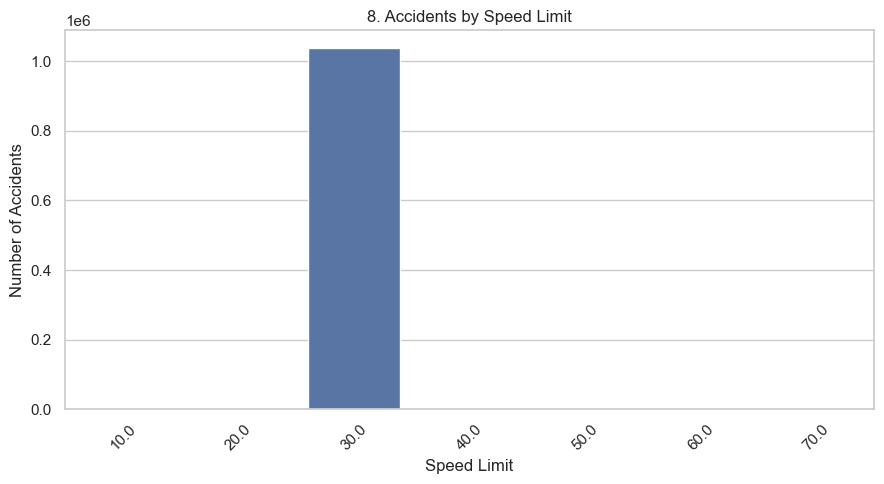

In [10]:
counts = df["Speed_limit"].value_counts().sort_index()
print(counts)

plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Speed_limit", order=counts.index)
plt.title("8. Accidents by Speed Limit")
plt.xlabel("Speed Limit")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Accidents by Road Type

Road_Type
1.0       2996
2.0       1631
3.0       8783
6.0    1034223
7.0        470
9.0        472
Name: count, dtype: int64


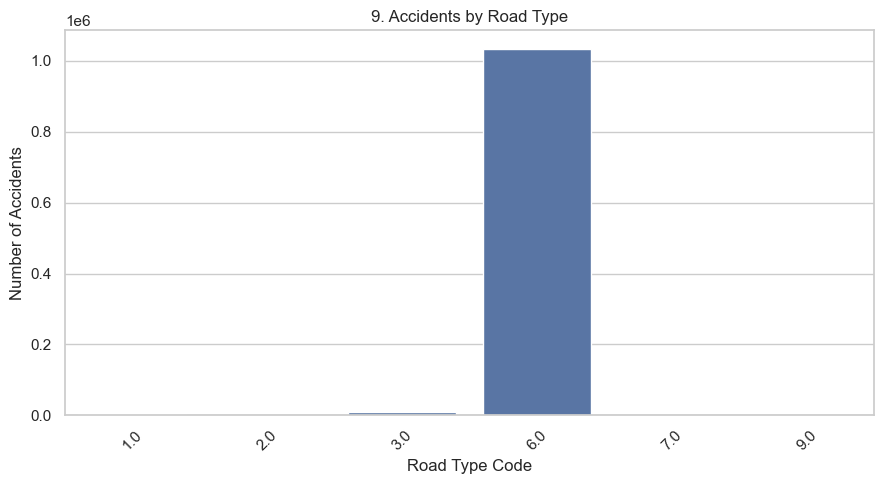

In [11]:
counts = df["Road_Type"].value_counts().sort_index()
print(counts)

plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Road_Type", order=counts.index)
plt.title("9. Accidents by Road Type")
plt.xlabel("Road Type Code")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Accidents by Weather Conditions

Weather_Conditions
1.0    1038384
2.0       7075
3.0        406
4.0        582
5.0        522
6.0         49
7.0        228
8.0        756
9.0        573
Name: count, dtype: int64


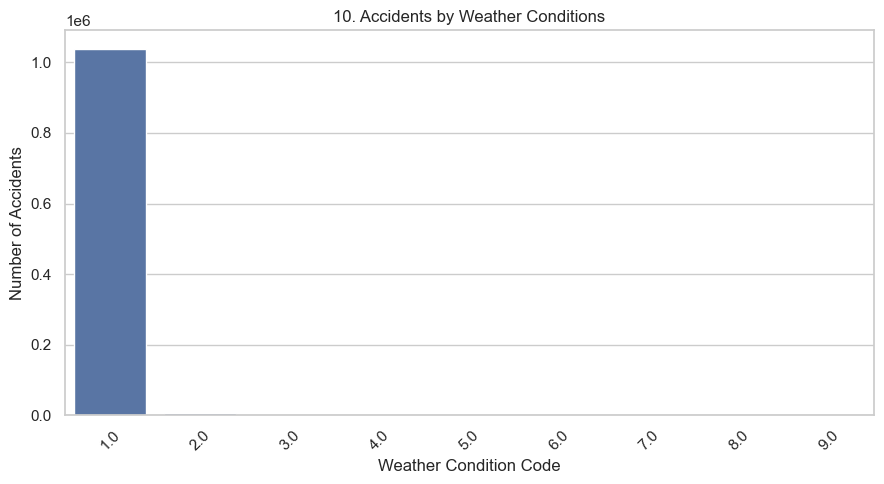

In [12]:
counts = df["Weather_Conditions"].value_counts().sort_index()
print(counts)

plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Weather_Conditions", order=counts.index)
plt.title("10. Accidents by Weather Conditions")
plt.xlabel("Weather Condition Code")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Accidents by Light Conditions

Light_Conditions
1.0    1031757
4.0      14969
5.0        244
6.0       1352
7.0        253
Name: count, dtype: int64


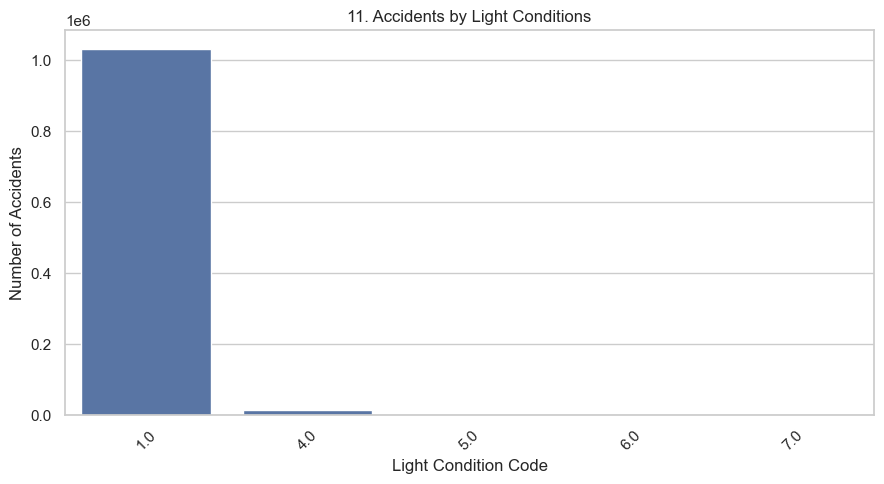

In [13]:
counts = df["Light_Conditions"].value_counts().sort_index()
print(counts)

plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Light_Conditions", order=counts.index)
plt.title("11. Accidents by Light Conditions")
plt.xlabel("Light Condition Code")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. Accidents by Road Surface Conditions

Road_Surface_Conditions
-1.0         50
 1.0    1032138
 2.0      15489
 3.0        231
 4.0        617
 5.0         50
Name: count, dtype: int64


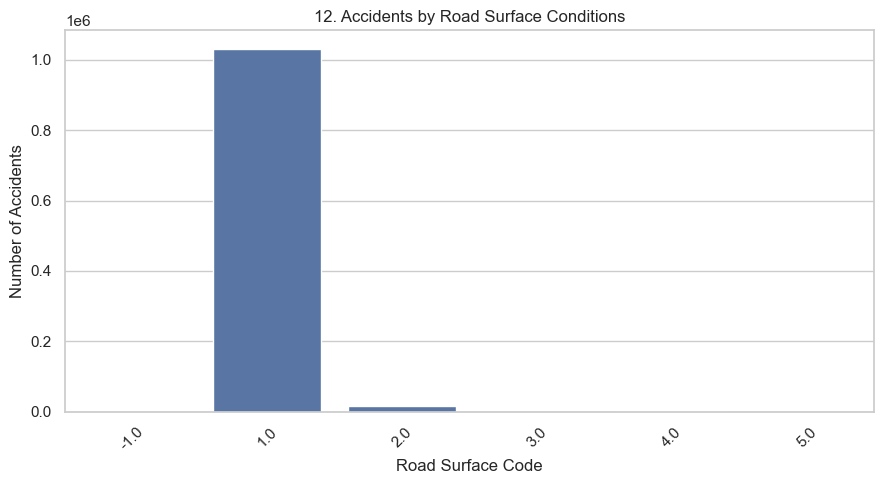

In [14]:
counts = df["Road_Surface_Conditions"].value_counts().sort_index()
print(counts)

plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Road_Surface_Conditions", order=counts.index)
plt.title("12. Accidents by Road Surface Conditions")
plt.xlabel("Road Surface Code")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. Accidents by Urban/Rural Area

Urban_or_Rural_Area
1.0    1037478
2.0      11073
3.0         24
Name: count, dtype: int64


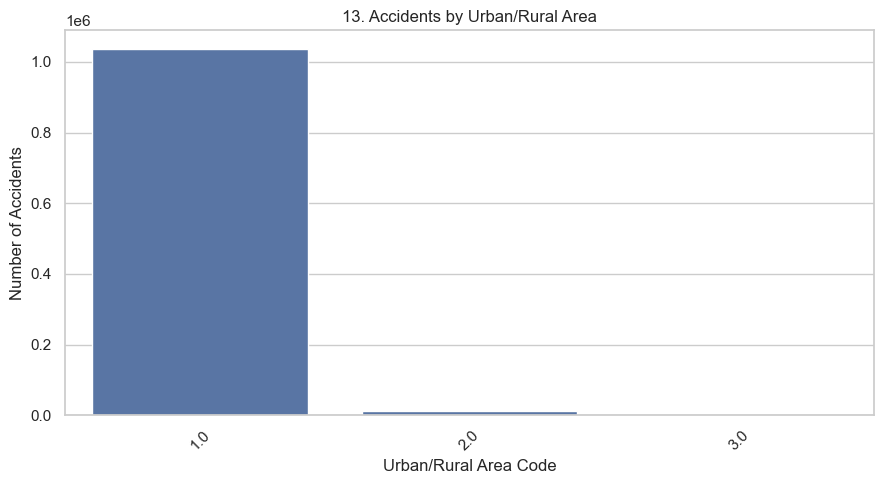

In [15]:
counts = df["Urban_or_Rural_Area"].value_counts().sort_index()
print(counts)

plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Urban_or_Rural_Area", order=counts.index)
plt.title("13. Accidents by Urban/Rural Area")
plt.xlabel("Urban/Rural Area Code")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 14. Accident Time — Hourly Distribution

Hour
0        998
1        736
2        640
3        384
4        285
5        380
6        847
7       2131
8       3938
9       2935
10      2686
11      3029
12      3663
13      3704
14      3517
15    993304
16      4727
17      5165
18      4191
19      3337
20      2627
21      2071
22      1714
23      1566
Name: count, dtype: int64


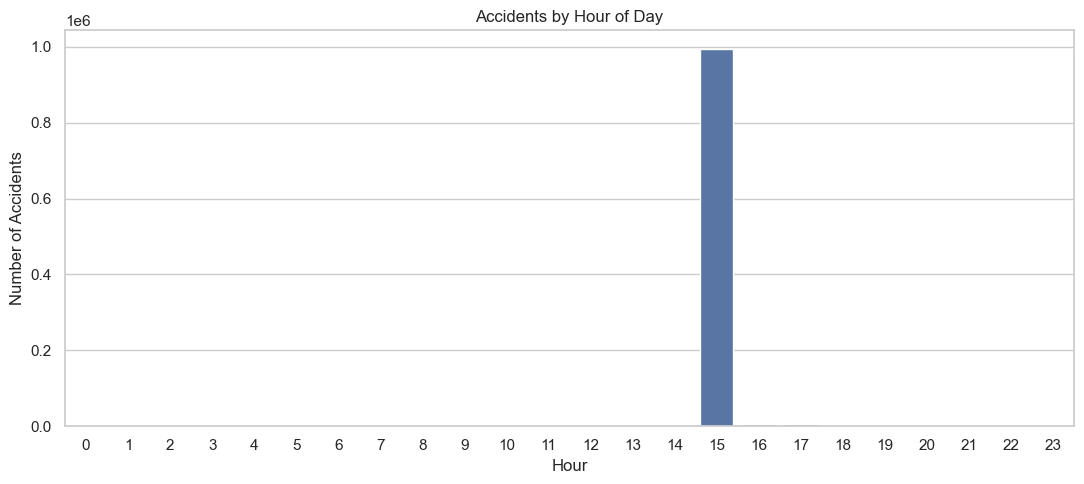

In [16]:
df_eda = df.copy()
df_eda["Hour"] = pd.to_datetime(df_eda["Time"], format="%H:%M", errors="coerce").dt.hour
print(df_eda["Hour"].value_counts().sort_index())

plt.figure(figsize=(11,5))
sns.countplot(data=df_eda, x="Hour", order=range(24))
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

# PART B — BIVARIATE ANALYSIS
Bivariate analysis examines the relationship between **two variables**.


## 15. Accident Severity vs Number of Casualties

                     count      mean  median   max
Accident_Severity                                 
1.0                    646  1.860681     1.0  13.0
2.0                   7377  1.421445     1.0  17.0
3.0                1040552  1.014973     1.0  23.0


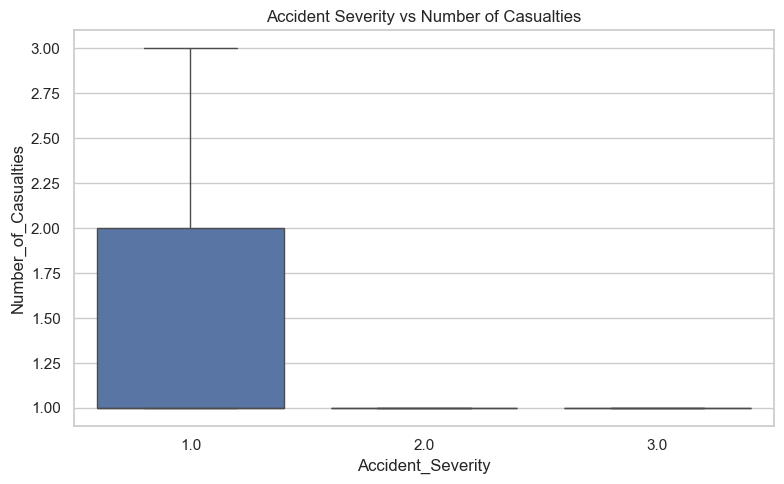

In [17]:
print(df.groupby("Accident_Severity")["Number_of_Casualties"].agg(["count","mean","median","max"]))
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Accident_Severity", y="Number_of_Casualties", showfliers=False)
plt.title("Accident Severity vs Number of Casualties")
plt.tight_layout()
plt.show()

## 16. Number of Vehicles vs Number of Casualties

                      Number_of_Vehicles  Number_of_Casualties
Number_of_Vehicles              1.000000              0.118868
Number_of_Casualties            0.118868              1.000000


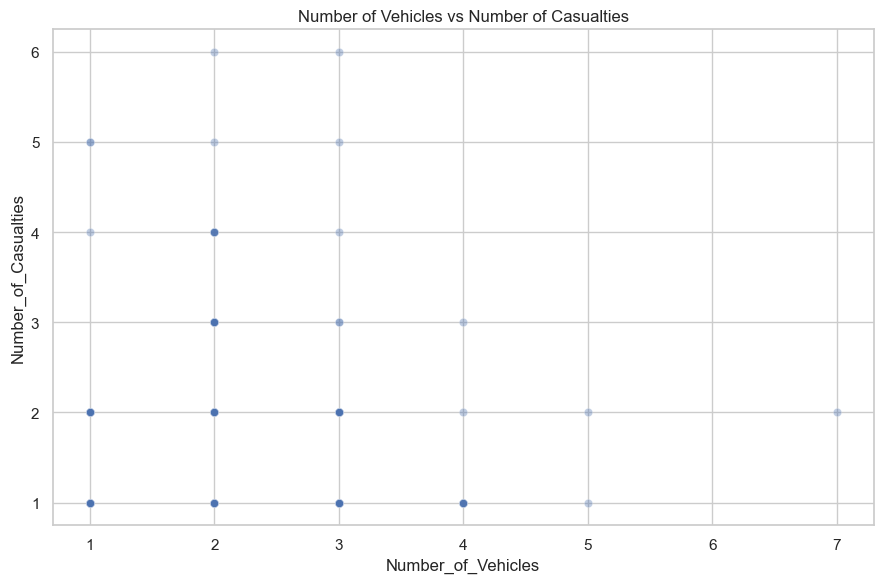

In [18]:
print(df[["Number_of_Vehicles","Number_of_Casualties"]].corr())
sample = df.sample(min(10000, len(df)), random_state=42)
plt.figure(figsize=(9,6))
sns.scatterplot(data=sample, x="Number_of_Vehicles", y="Number_of_Casualties", alpha=.35)
plt.title("Number of Vehicles vs Number of Casualties")
plt.tight_layout()
plt.show()

## 17. Weather Conditions vs Accident Severity

Accident_Severity,1.0,2.0,3.0
Weather_Conditions,,,
1.0,542,6265,1031577
2.0,64,764,6247
3.0,3,32,371
4.0,13,66,503
5.0,7,83,432
6.0,2,9,38
7.0,3,30,195
8.0,4,75,677
9.0,8,53,512


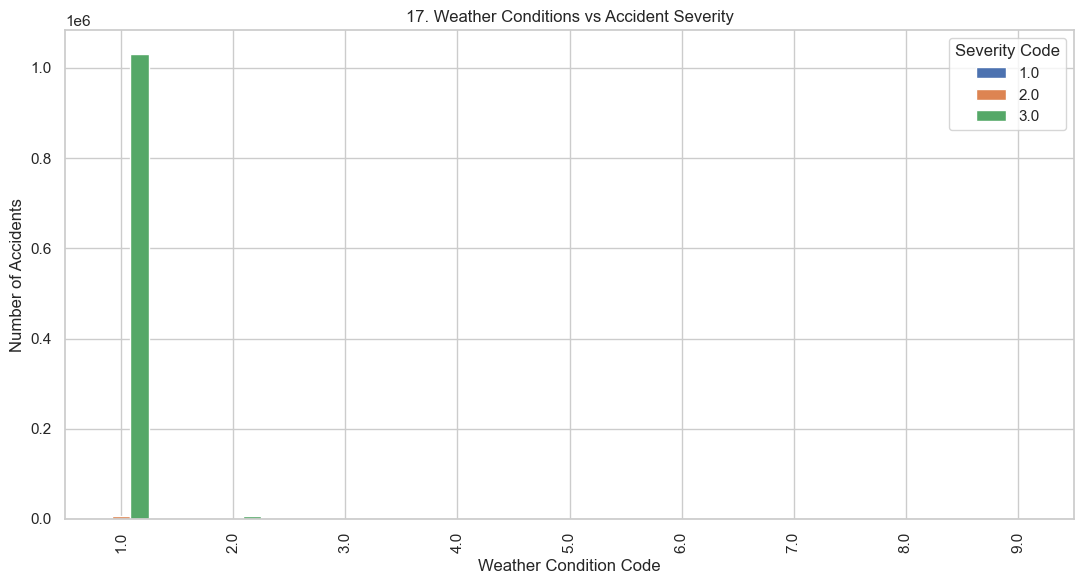

In [19]:
table = pd.crosstab(df["Weather_Conditions"], df["Accident_Severity"])
display(table)
table.plot(kind="bar", figsize=(11,6))
plt.title("17. Weather Conditions vs Accident Severity")
plt.xlabel("Weather Condition Code")
plt.ylabel("Number of Accidents")
plt.legend(title="Severity Code")
plt.tight_layout()
plt.show()

## 18. Light Conditions vs Accident Severity

Accident_Severity,1.0,2.0,3.0
Light_Conditions,,,
1.0,361,4907,1026489
4.0,220,2096,12653
5.0,5,34,205
6.0,56,300,996
7.0,4,40,209


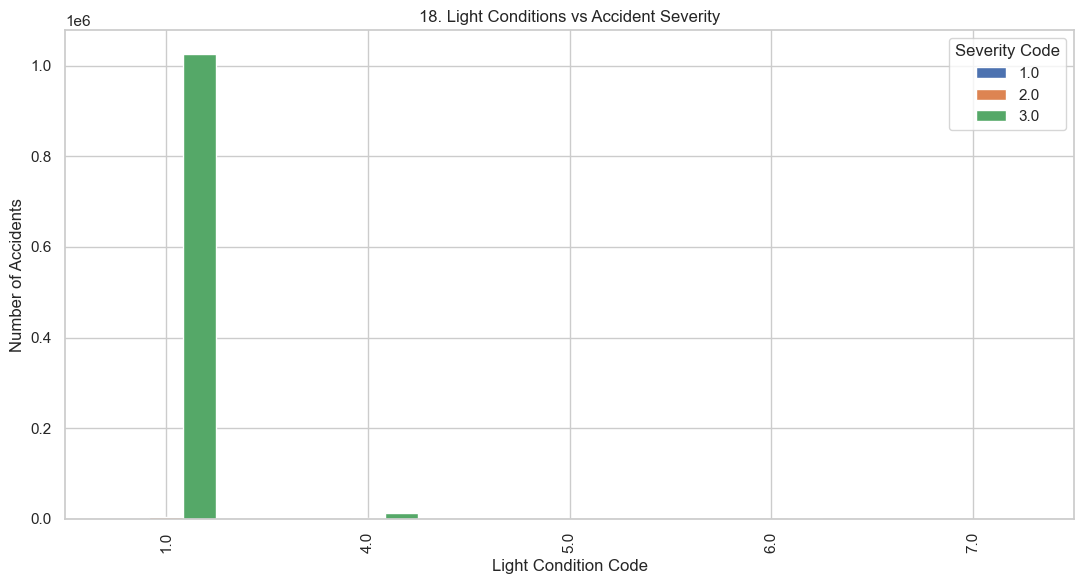

In [20]:
table = pd.crosstab(df["Light_Conditions"], df["Accident_Severity"])
display(table)
table.plot(kind="bar", figsize=(11,6))
plt.title("18. Light Conditions vs Accident Severity")
plt.xlabel("Light Condition Code")
plt.ylabel("Number of Accidents")
plt.legend(title="Severity Code")
plt.tight_layout()
plt.show()

## 19. Road Surface Conditions vs Accident Severity

Accident_Severity,1.0,2.0,3.0
Road_Surface_Conditions,,,
-1.0,1,6,43
1.0,428,5405,1026305
2.0,206,1861,13422
3.0,2,25,204
4.0,8,70,539
5.0,1,10,39


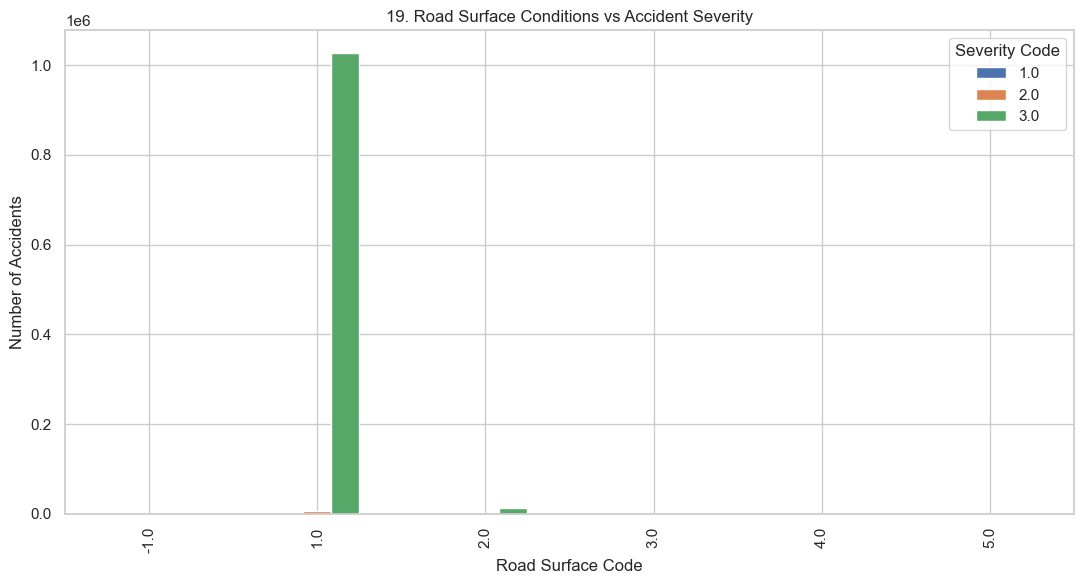

In [21]:
table = pd.crosstab(df["Road_Surface_Conditions"], df["Accident_Severity"])
display(table)
table.plot(kind="bar", figsize=(11,6))
plt.title("19. Road Surface Conditions vs Accident Severity")
plt.xlabel("Road Surface Code")
plt.ylabel("Number of Accidents")
plt.legend(title="Severity Code")
plt.tight_layout()
plt.show()

## 20. Speed Limit vs Accident Severity

Accident_Severity,1.0,2.0,3.0
Speed_limit,,,
10.0,0,0,1
20.0,2,40,214
30.0,359,5516,1030627
40.0,44,424,2660
50.0,23,198,1143
60.0,147,897,3521
70.0,71,302,2386


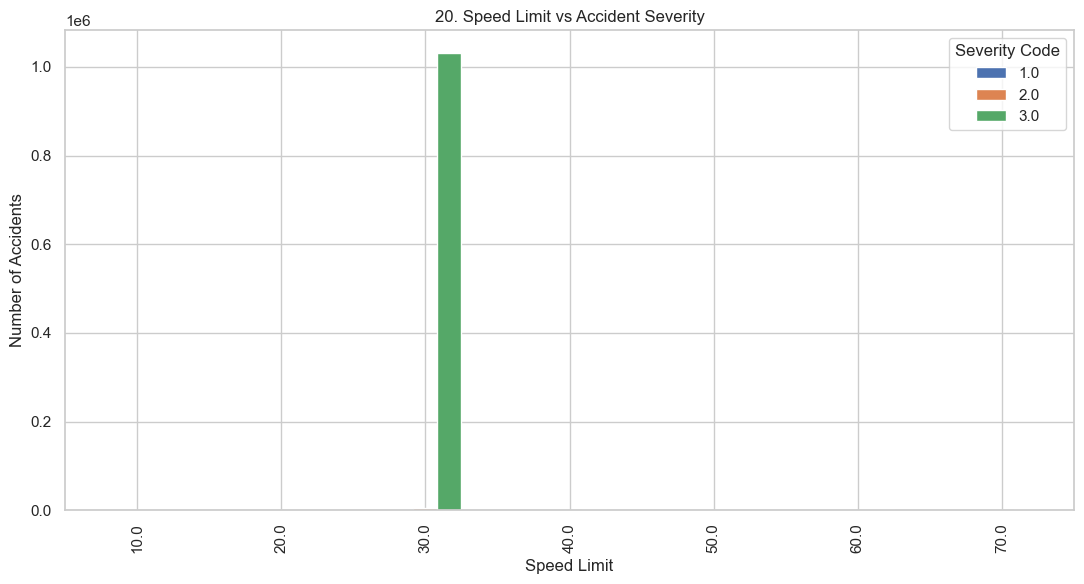

In [22]:
table = pd.crosstab(df["Speed_limit"], df["Accident_Severity"])
display(table)
table.plot(kind="bar", figsize=(11,6))
plt.title("20. Speed Limit vs Accident Severity")
plt.xlabel("Speed Limit")
plt.ylabel("Number of Accidents")
plt.legend(title="Severity Code")
plt.tight_layout()
plt.show()

## 21. Urban/Rural Area vs Accident Severity

Accident_Severity,1.0,2.0,3.0
Urban_or_Rural_Area,,,
1.0,381,5656,1031441
2.0,265,1716,9092
3.0,0,5,19


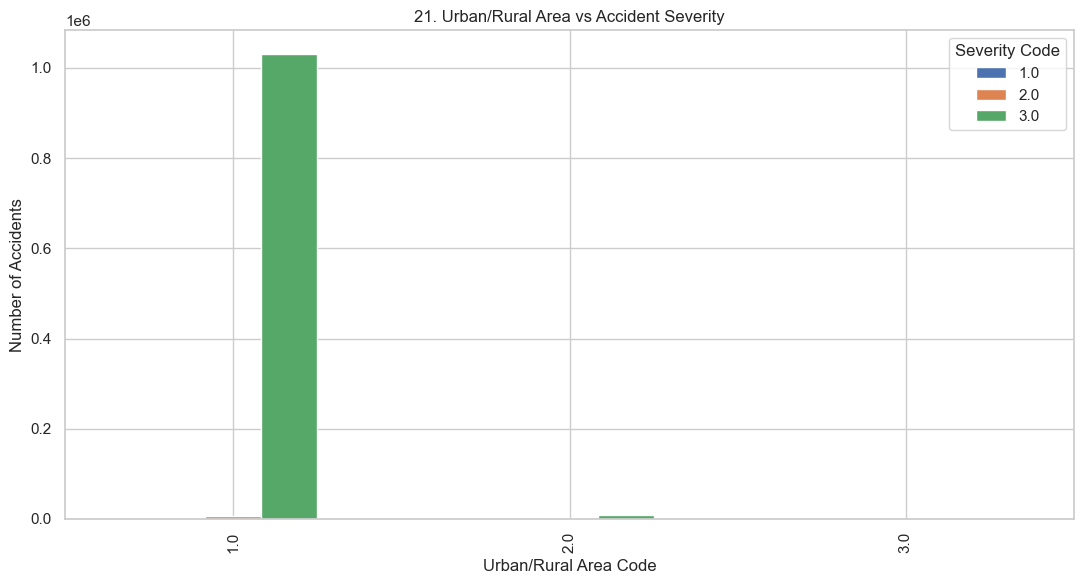

In [23]:
table = pd.crosstab(df["Urban_or_Rural_Area"], df["Accident_Severity"])
display(table)
table.plot(kind="bar", figsize=(11,6))
plt.title("21. Urban/Rural Area vs Accident Severity")
plt.xlabel("Urban/Rural Area Code")
plt.ylabel("Number of Accidents")
plt.legend(title="Severity Code")
plt.tight_layout()
plt.show()

## 22. Day of Week vs Number of Casualties

,count,mean,sum
Day_of_Week,,,
1.0,6544,1.412439,9243.0
2.0,8407,1.292375,10865.0
3.0,9018,1.283211,11572.0
4.0,997752,1.002623,1000369.0
5.0,8914,1.301548,11602.0
6.0,9792,1.304841,12777.0
7.0,8148,1.398135,11392.0


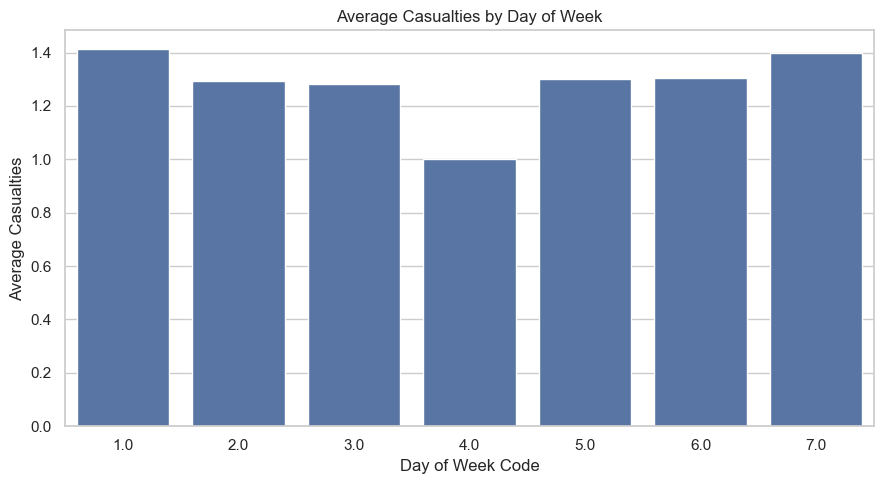

In [24]:
display(df.groupby("Day_of_Week")["Number_of_Casualties"].agg(["count","mean","sum"]))
plt.figure(figsize=(9,5))
sns.barplot(data=df, x="Day_of_Week", y="Number_of_Casualties", estimator=np.mean, errorbar=None)
plt.title("Average Casualties by Day of Week")
plt.xlabel("Day of Week Code")
plt.ylabel("Average Casualties")
plt.tight_layout()
plt.show()

## 23. Hour of Day vs Accident Severity

Accident_Severity,1.0,2.0,3.0
Hour,,,
0,27,169,802
1,27,146,563
2,22,139,479
3,14,71,299
4,9,45,231
5,9,58,313
6,16,143,688
7,20,240,1871
8,21,400,3517


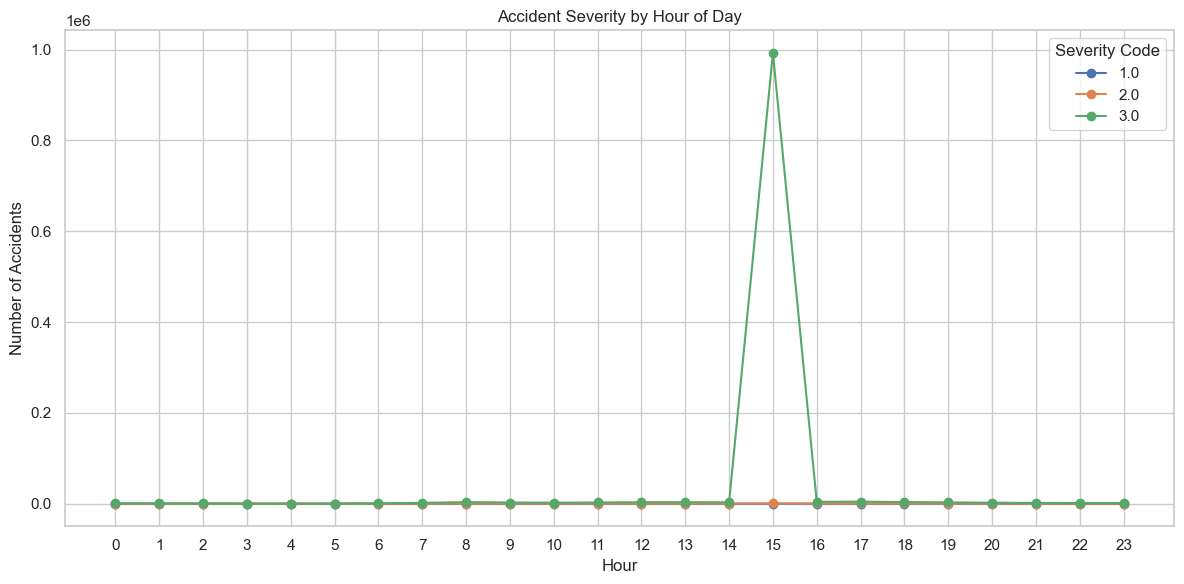

In [25]:
hour_severity = pd.crosstab(df_eda["Hour"], df_eda["Accident_Severity"])
display(hour_severity)
hour_severity.plot(kind="line", marker="o", figsize=(12,6))
plt.title("Accident Severity by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.xticks(range(24))
plt.legend(title="Severity Code")
plt.tight_layout()
plt.show()

## 24. Correlation Heatmap

,Number_of_Vehicles,Number_of_Casualties,Speed_limit,Accident_Severity,longitude,latitude
Number_of_Vehicles,1.000000,0.118868,0.008709,0.174638,-0.068533,0.032648
Number_of_Casualties,0.118868,1.000000,0.273730,-0.202549,-0.015775,0.004577
Speed_limit,0.008709,0.273730,1.000000,-0.199425,-0.100125,-0.082230
Accident_Severity,0.174638,-0.202549,-0.199425,1.000000,-0.009596,0.001987
longitude,-0.068533,-0.015775,-0.100125,-0.009596,1.000000,0.336237
latitude,0.032648,0.004577,-0.082230,0.001987,0.336237,1.000000


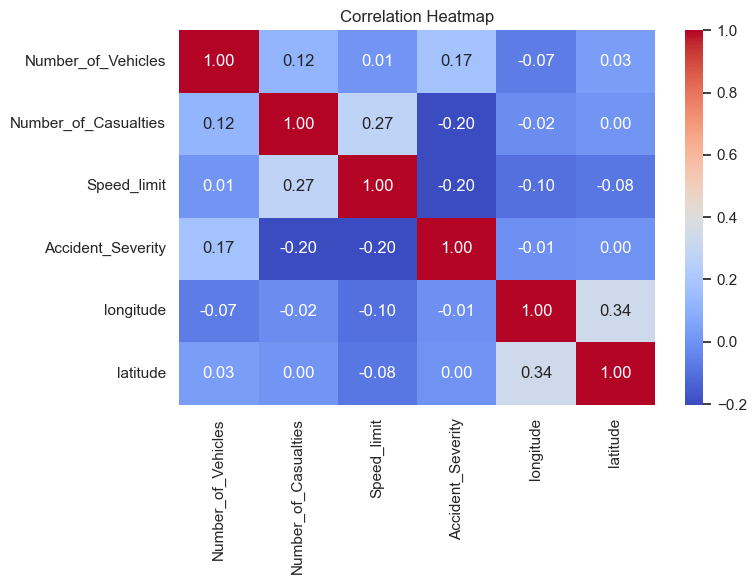

In [26]:
corr_cols = ["Number_of_Vehicles","Number_of_Casualties","Speed_limit",
             "Accident_Severity","longitude","latitude"]
corr = df[corr_cols].corr(numeric_only=True)
display(corr)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Week 4 — Conclusion

### Univariate Analysis Completed
Accident severity, vehicles, casualties, day of week, speed limit, road type, weather, light, road surface, urban/rural area, and hour of day were analyzed individually.

### Bivariate Analysis Completed
Relationships were examined between severity and casualties, vehicles and casualties, environmental conditions and severity, speed limit and severity, urban/rural area and severity, day of week and casualties, and hour and severity. A correlation heatmap was also produced for selected numerical variables.

The Week 4 EDA provides the visualization and statistical foundation for interpreting patterns in the cleaned road-accident dataset.
